# 🧠 AI CRM Brain — Sprint 2
## Phase 3: Model Training & Evaluation

---

> **Where we are:** Phases 1 & 2 are done. We have clean, scaled, split data.  
> **What we do here:** Train a machine learning model, measure how good it is, and understand *why* it makes each prediction.

---

### What is the model going to do?

Given a deal's features (Amount, Owner, Account, Closing Month, etc.),  
predict which **Stage** it belongs to:

```
Input  →  [Amount=1054, Owner_Freq=120, Close_Month=3, ...]
Output →  "Won"  (with 87% confidence)
```

---

### Steps in this notebook

| Step | What we do |
|---|---|
| 1 | Setup & reload preprocessed data |
| 2 | Train a Random Forest model |
| 3 | Make predictions |
| 4 | Measure accuracy |
| 5 | Confusion matrix — see where it gets confused |
| 6 | Full classification report |
| 7 | ROC-AUC curves — advanced evaluation |
| 8 | Feature importance — what drives predictions? |
| 9 | Save the trained model |
| 10 | Summary |

---

## Step 1 — Setup & Reload Data

We load the artefacts saved in Phase 2 — the cleaned, scaled, split datasets  
and the encoders. **We do not re-run any preprocessing here.**

In [3]:
# ── Imports ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import json
import warnings
from pathlib import Path
from itertools import cycle

# Scikit-learn — model and metrics
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.preprocessing   import label_binarize

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'        : 120,
    'figure.facecolor'  : 'white',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

STAGE_COLOURS = {
    'Won': '#16A34A', 'Lost': '#DC2626',
    'Engaging': '#2563EB', 'Prospecting': '#D97706',
}

ARTEFACTS_DIR  = Path('/kaggle/input/datasets/tamerelkot/instances')
MODEL_DIR      = Path('/kaggle/working/weights')
MODEL_DIR.mkdir(exist_ok=True)
PLOTS_DIR      = Path('/kaggle/working/dashboard')
PLOTS_DIR.mkdir(exist_ok=True)

print("✅ Imports successful.")
print(f"   Loading data from : {ARTEFACTS_DIR.resolve()}")
print(f"   Saving models to  : {MODEL_DIR.resolve()}")

✅ Imports successful.
   Loading data from : /kaggle/input/datasets/tamerelkot/instances
   Saving models to  : /kaggle/working/weights


In [4]:
# ── Reload preprocessed artefacts from Phase 2 ─────────────────

# Encoders and scaler
with open(ARTEFACTS_DIR / 'label_encoder_stage.pkl', 'rb') as f:
    label_enc = pickle.load(f)

with open(ARTEFACTS_DIR / 'standard_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open(ARTEFACTS_DIR / 'frequency_maps.json') as f:
    freq_maps = json.load(f)

# Feature metadata
with open(ARTEFACTS_DIR / 'feature_columns.json') as f:
    meta          = json.load(f)
    FEATURE_COLS  = meta['features']
    TARGET_COL    = meta['target']
    STAGE_MAPPING = meta['stage_mapping']   # e.g. {'Won': 3, 'Lost': 1, ...}

In [6]:
STAGE_MAPPING

{'Engaging': 0, 'Lost': 1, 'Prospecting': 2, 'Won': 3}

In [5]:
FEATURE_COLS

['Amount',
 'Close_Month',
 'Close_Year',
 'Close_Quarter',
 'Close_DayOfWeek',
 'Deal_Age_Days',
 'Owner_Freq',
 'Account_Freq']

In [7]:
# Reverse mapping: number → stage name  (e.g. 3 → 'Won')
IDX_TO_STAGE = {v: k for k, v in STAGE_MAPPING.items()}
IDX_TO_STAGE

{0: 'Engaging', 1: 'Lost', 2: 'Prospecting', 3: 'Won'}

In [12]:
X_train = pd.read_csv('/kaggle/input/datasets/tamerelkot/sales-crm/X_train.csv')
X_val   = pd.read_csv('/kaggle/input/datasets/tamerelkot/sales-crm/X_val.csv')
X_test  = pd.read_csv('/kaggle/input/datasets/tamerelkot/sales-crm/X_test.csv')
y_train = pd.read_csv('/kaggle/input/datasets/tamerelkot/sales-crm/y_train.csv').squeeze()
y_val   = pd.read_csv('/kaggle/input/datasets/tamerelkot/sales-crm/y_val.csv').squeeze()
y_test  = pd.read_csv('/kaggle/input/datasets/tamerelkot/sales-crm/y_test.csv').squeeze()

In [11]:
X_train.shape

(6160, 8)

In [15]:






print(f"   X_train : {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f"   X_val   : {X_val.shape[0]:,} rows × {X_val.shape[1]} features")
print(f"   X_test  : {X_test.shape[0]:,} rows × {X_test.shape[1]} features")
print()
print(f"   Stage classes  : {label_enc.classes_.tolist()}")
print(f"   Feature columns: {FEATURE_COLS}")

   X_train : 6,160 rows × 8 features
   X_val   : 1,320 rows × 8 features
   X_test  : 1,320 rows × 8 features

   Stage classes  : ['Engaging', 'Lost', 'Prospecting', 'Won']
   Feature columns: ['Amount', 'Close_Month', 'Close_Year', 'Close_Quarter', 'Close_DayOfWeek', 'Deal_Age_Days', 'Owner_Freq', 'Account_Freq']


In [16]:
X_train.head()

,Amount,Close_Month,Close_Year,Close_Quarter,Close_DayOfWeek,Deal_Age_Days,Owner_Freq,Account_Freq
0,-0.615248,-0.111057,0.558100,0.057631,-0.426883,-0.261155,0.056709,-0.473040
1,-0.379273,0.571008,0.558100,0.605480,0.806705,0.462986,0.676920,-0.446960
2,2.215462,0.343653,0.558100,0.605480,-0.015687,0.304270,-0.494590,-0.423778
3,-0.380763,-1.475188,-1.791794,-1.585917,-1.249274,-1.163850,-0.533968,2.265374
4,0.995345,-0.338412,0.558100,0.057631,1.629096,-0.558746,-1.380605,-0.446960


---
## Step 2 — What is a Random Forest?

Before we train, let's quickly understand the model.

### Decision Tree (the building block)

A decision tree asks a series of yes/no questions about a deal:

```
Is Amount > $2,000?
├── YES → Is Close_Month > 9?
│         ├── YES → Predict: Won  ✅
│         └── NO  → Predict: Engaging
└── NO  → Is Owner_Freq > 50?
          ├── YES → Predict: Lost
          └── NO  → Predict: Prospecting
```

### Random Forest = Many trees voting together

Instead of one tree, we grow **100+ trees** — each one trained on a  
slightly different random subset of the data and features.  
Each tree votes, and the **majority vote** wins.

```
Tree 1  →  Won
Tree 2  →  Won
Tree 3  →  Engaging
Tree 4  →  Won
...
Tree 100 →  Won

Final answer: Won  (voted by 78 out of 100 trees → 78% confidence)
```

### Why Random Forest for this problem?

| Property | Benefit |
|---|---|
| Handles mixed data types | Amount + encoded categoricals work together |
| Robust to outliers | Big Amount values won't break it |
| Built-in feature importance | Tells us *why* it predicts each stage |
| No data scaling required | (We scaled anyway — good practice) |
| Works well with imbalanced classes | We add `class_weight='balanced'` |

---
## Step 3 — Train the Model

We train our Random Forest on the **training set only**.  
The validation set is used immediately after to check performance.

In [32]:
# ── Define the model ────────────────────────────────────────────
#
# Key parameters explained:
#   n_estimators=200     → grow 200 trees (more = more stable, slower)
#   max_depth=None       → let trees grow as deep as needed
#   min_samples_leaf=5   → each leaf needs at least 5 deals (prevents overfitting)
#   class_weight='balanced' → auto-compensates for imbalanced classes
#   random_state=42      → fixed seed → same result every time you run this
#   n_jobs=-1            → use all CPU cores to train faster

model = RandomForestClassifier(
    n_estimators    = 1000,
    max_depth       = 200,
    min_samples_leaf= 5,
    class_weight    = 'balanced',
    random_state    = 42,
    n_jobs          = -1,
)

print("✅ Random Forest defined.")
print()
print("── Model Parameters ──────────────────────────────────────────")
params = model.get_params()
for k, v in params.items():
    print(f"   {k:<25} : {v}")

✅ Random Forest defined.

── Model Parameters ──────────────────────────────────────────
   bootstrap                 : True
   ccp_alpha                 : 0.0
   class_weight              : balanced
   criterion                 : gini
   max_depth                 : 200
   max_features              : sqrt
   max_leaf_nodes            : None
   max_samples               : None
   min_impurity_decrease     : 0.0
   min_samples_leaf          : 5
   min_samples_split         : 2
   min_weight_fraction_leaf  : 0.0
   monotonic_cst             : None
   n_estimators              : 1000
   n_jobs                    : -1
   oob_score                 : False
   random_state              : 42
   verbose                   : 0
   warm_start                : False


In [35]:
# ── Train the model ─────────────────────────────────────────────
import time

print("Training Random Forest on training set...")
print(f"   Training rows : {X_train.shape[0]:,}")
print(f"   Features      : {X_train.shape[1]}")
print()

start = time.time()
model.fit(X_train, y_train)
elapsed = time.time() - start

print(f" Training complete in {elapsed:.1f} seconds.")
print()

Training Random Forest on training set...
   Training rows : 6,160
   Features      : 8

 Training complete in 3.0 seconds.



In [36]:


# Quick check: training accuracy (should be high — model memorises training data)
train_acc = model.score(X_train, y_train) * 100
val_acc   = model.score(X_val,   y_val)   * 100

print(f"   Training Accuracy   : {train_acc:.1f}%")
print(f"   Validation Accuracy : {val_acc:.1f}%")
gap = train_acc - val_acc
print()
if gap < 5:
    print(f"    Gap ({gap:.1f}%) is small — model generalises well.")
elif gap < 15:
    print(f"     Gap ({gap:.1f}%) is moderate — slight overfitting, acceptable for now.")
else:
    print(f"    Gap ({gap:.1f}%) is large — model is overfitting. Consider reducing depth.")

   Training Accuracy   : 94.5%
   Validation Accuracy : 93.6%

    Gap (0.9%) is small — model generalises well.


---
## Step 4 — Make Predictions

After training, we ask the model to predict stage labels for deals  
it has **never seen before** — the validation set.

The model returns two things:
- **`y_pred`** — the predicted stage label (e.g. 2 = "Won")
- **`y_prob`** — the probability for each class (e.g. [0.05, 0.10, 0.07, 0.78])

In [ ]:
# Predict on validation set
y_pred      = model.predict(X_val)        # Class labels (integers)
y_prob      = model.predict_proba(X_val)  # Probability per class (shape: n_rows × 4)

In [ ]:
# Convert integer labels back to stage names for readability
y_val_names  = pd.Series(y_val).map(IDX_TO_STAGE)
y_pred_names = pd.Series(y_pred).map(IDX_TO_STAGE)

In [39]:
y_val_names, y_pred_names

(0               Won
 1              Lost
 2               Won
 3          Engaging
 4          Engaging
            ...     
 1315       Engaging
 1316    Prospecting
 1317            Won
 1318            Won
 1319            Won
 Name: Stage_Encoded, Length: 1320, dtype: object,
 0               Won
 1              Lost
 2               Won
 3       Prospecting
 4          Engaging
            ...     
 1315       Engaging
 1316    Prospecting
 1317            Won
 1318            Won
 1319            Won
 Length: 1320, dtype: object)

In [37]:
print(" Predictions generated.")
print()
print("── Sample Predictions (first 10) ────────────────────────────")
sample = pd.DataFrame({
    'Actual Stage'   : y_val_names.values[:10],
    'Predicted Stage': y_pred_names[:10],
    'Confidence'     : [f"{max(p)*100:.1f}%" for p in y_prob[:10]],
    'Correct?'       : ['✅' if a == p else '❌'
                        for a, p in zip(y_val_names.values[:10], y_pred_names[:10])],
})
display(sample)

✅ Predictions generated.

── Sample Predictions (first 10) ────────────────────────────


,Actual Stage,Predicted Stage,Confidence,Correct?
0,Won,Won,97.2%,✅
1,Lost,Lost,97.7%,✅
2,Won,Won,96.6%,✅
3,Engaging,Prospecting,51.6%,❌
4,Engaging,Engaging,86.1%,✅
5,Won,Won,98.0%,✅
6,Won,Won,96.2%,✅
7,Won,Won,98.4%,✅
8,Won,Won,96.9%,✅
9,Won,Won,97.2%,✅


In [40]:
# Show the probability output for one deal — this is what goes to the dashboard
idx = 0   # change this to inspect any row

print(f"── Probability Breakdown for Deal #{idx} ──────────────────────")
print()
for class_idx, prob in enumerate(y_prob[idx]):
    stage = IDX_TO_STAGE[class_idx]
    bar   = '█' * int(prob * 40)
    print(f"   {stage:<15} {prob*100:>5.1f}%  {bar}")

print()
print(f"   → Model predicts: {IDX_TO_STAGE[y_pred[idx]]}")
print(f"   → Actual stage  : {y_val_names.values[idx]}")

── Probability Breakdown for Deal #0 ──────────────────────

   Engaging          0.0%  
   Lost              2.8%  █
   Prospecting       0.0%  
   Won              97.2%  ██████████████████████████████████████

   → Model predicts: Won
   → Actual stage  : Won


---
## Step 5 — Measure Accuracy

**Accuracy** = the percentage of deals the model predicted correctly.

But accuracy alone is not enough for imbalanced classes.  
We also measure **Precision**, **Recall**, and **F1-Score** per class.

| Metric | Plain English |
|---|---|
| **Accuracy** | Out of all deals, how many did we get right? |
| **Precision** | When we say "Won", how often are we correct? |
| **Recall** | Out of all actual "Won" deals, how many did we catch? |
| **F1-Score** | Balance between Precision and Recall (use when classes are unequal) |

In [41]:
# ── Core metrics ─────────────────────────────────────────────────
accuracy  = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average='weighted')
recall    = recall_score(y_val, y_pred, average='weighted')
f1        = f1_score(y_val, y_pred, average='weighted')

print("=" * 52)
print("  MODEL PERFORMANCE — VALIDATION SET")
print("=" * 52)
print(f"  Accuracy  : {accuracy*100:>6.2f}%")
print(f"  Precision : {precision*100:>6.2f}%  (weighted avg)")
print(f"  Recall    : {recall*100:>6.2f}%  (weighted avg)")
print(f"  F1-Score  : {f1*100:>6.2f}%  (weighted avg)")
print("=" * 52)

# Grading
if accuracy >= 0.85:
    grade = "🟢 Excellent"
elif accuracy >= 0.70:
    grade = "🟡 Good"
elif accuracy >= 0.55:
    grade = "🟠 Fair — needs improvement"
else:
    grade = "🔴 Poor — revisit preprocessing"

print(f"\n  Overall grade: {grade}")

  MODEL PERFORMANCE — VALIDATION SET
  Accuracy  :  93.64%
  Precision :  96.13%  (weighted avg)
  Recall    :  93.64%  (weighted avg)
  F1-Score  :  94.10%  (weighted avg)

  Overall grade: 🟢 Excellent


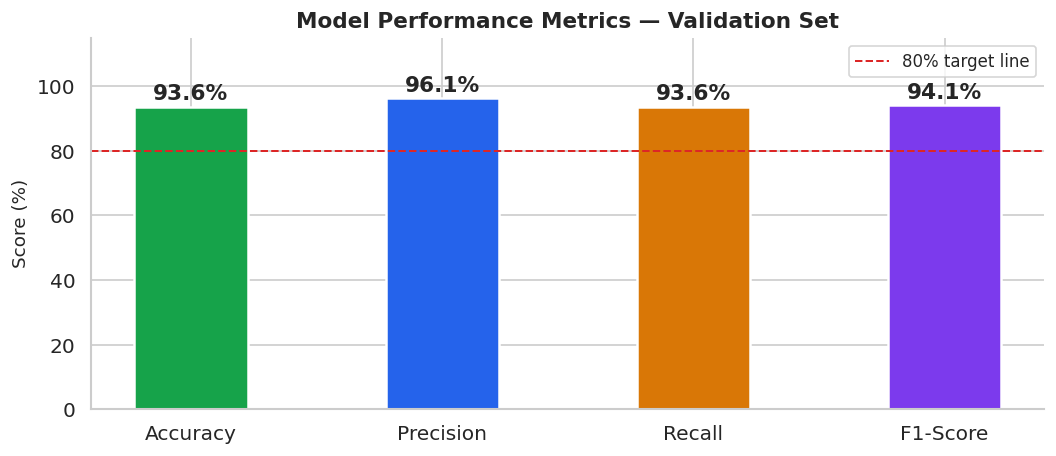

✅ Chart saved.


In [42]:
# ── Visual metric bar chart ──────────────────────────────────────
metrics = {
    'Accuracy' : accuracy,
    'Precision': precision,
    'Recall'   : recall,
    'F1-Score' : f1,
}
colours = ['#16A34A','#2563EB','#D97706','#7C3AED']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(metrics.keys(), [v*100 for v in metrics.values()],
              color=colours, edgecolor='white', linewidth=1.5, width=0.45)

for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f'{val*100:.1f}%',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Model Performance Metrics — Validation Set',
             fontweight='bold', fontsize=13)
ax.axhline(y=80, color='#DC2626', linestyle='--',
           linewidth=1.2, label='80% target line')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'performance_metrics.png', bbox_inches='tight')
plt.show()
print("✅ Chart saved.")

---
## Step 6 — Confusion Matrix

A confusion matrix shows **exactly where** the model gets confused.

### How to read it:

- **Rows** = Actual stage (what the deal really is)
- **Columns** = Predicted stage (what our model said)
- **Diagonal** (top-left to bottom-right) = Correct predictions ✅
- **Off-diagonal** = Mistakes ❌

```
                Predicted:
                Won   Lost  Engaging  Prospecting
Actual: Won   [ 850    12      20         5   ]   ← 850 correct, 37 wrong
        Lost  [  15   480      18         3   ]
        ...
```

The brighter the diagonal, the better the model.

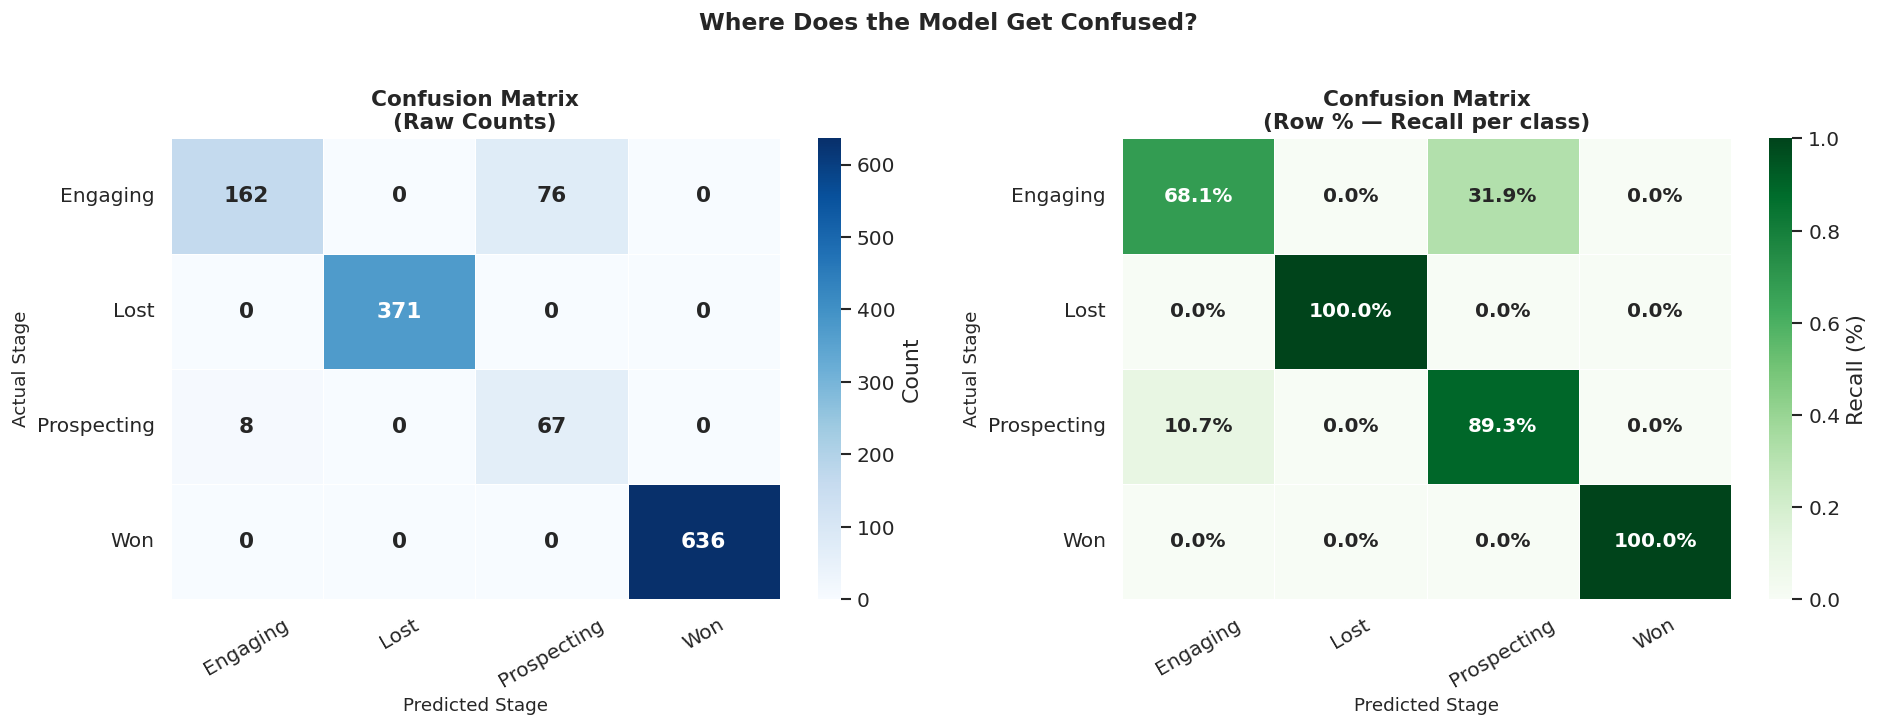

✅ Chart saved as 'model_plots/confusion_matrix.png'


In [46]:
# ── Compute confusion matrix ─────────────────────────────────────
cm     = confusion_matrix(y_val, y_pred)
labels = label_enc.classes_   # ['Engaging', 'Lost', 'Prospecting', 'Won']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: raw counts ─────────────────────────────────────────────
ax1 = axes[0]
sns.heatmap(
    cm,
    annot=True, fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='white',
    ax=ax1,
    cbar_kws={'label': 'Count'},
    annot_kws={'size': 13, 'weight': 'bold'},
)
ax1.set_title('Confusion Matrix\n(Raw Counts)', fontweight='bold', fontsize=13)
ax1.set_xlabel('Predicted Stage', fontsize=11)
ax1.set_ylabel('Actual Stage', fontsize=11)
ax1.tick_params(axis='x', rotation=30)
ax1.tick_params(axis='y', rotation=0)

# ── Right: normalised (row percentages) ──────────────────────────
ax2 = axes[1]
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # row-normalise
sns.heatmap(
    cm_norm,
    annot=True, fmt='.1%',
    cmap='Greens',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='white',
    ax=ax2,
    vmin=0, vmax=1,
    cbar_kws={'label': 'Recall (%)'},
    annot_kws={'size': 12, 'weight': 'bold'},
)
ax2.set_title('Confusion Matrix\n(Row % — Recall per class)', fontweight='bold', fontsize=13)
ax2.set_xlabel('Predicted Stage', fontsize=11)
ax2.set_ylabel('Actual Stage', fontsize=11)
ax2.tick_params(axis='x', rotation=30)
ax2.tick_params(axis='y', rotation=0)

plt.suptitle('Where Does the Model Get Confused?',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'confusion_matrix.png', bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'model_plots/confusion_matrix.png'")

In [47]:
# ── Read the confusion matrix in plain English ───────────────────
print("CONFUSION MATRIX — PLAIN ENGLISH INTERPRETATION")
print("=" * 58)
print()

for i, actual_stage in enumerate(labels):
    total_actual = cm[i].sum()
    correct      = cm[i][i]
    wrong        = total_actual - correct
    recall_pct   = correct / total_actual * 100

    print(f"  {actual_stage} (actual: {total_actual} deals)")
    print(f"  ├── Correctly predicted : {correct:>4}  ({recall_pct:.1f}% recall)")
    print(f"  └── Misclassified as    : {wrong:>4}")

    for j, pred_stage in enumerate(labels):
        if i != j and cm[i][j] > 0:
            print(f"        → {pred_stage:<15} : {cm[i][j]} deals")
    print()

CONFUSION MATRIX — PLAIN ENGLISH INTERPRETATION

  Engaging (actual: 238 deals)
  ├── Correctly predicted :  162  (68.1% recall)
  └── Misclassified as    :   76
        → Prospecting     : 76 deals

  Lost (actual: 371 deals)
  ├── Correctly predicted :  371  (100.0% recall)
  └── Misclassified as    :    0

  Prospecting (actual: 75 deals)
  ├── Correctly predicted :   67  (89.3% recall)
  └── Misclassified as    :    8
        → Engaging        : 8 deals

  Won (actual: 636 deals)
  ├── Correctly predicted :  636  (100.0% recall)
  └── Misclassified as    :    0



---
## Step 7 — Full Classification Report

The classification report gives **Precision, Recall, and F1** for every class,  
not just the overall weighted average.

This tells us which stages the model handles well and which need more data.

In [48]:
# Print the scikit-learn classification report
report_str = classification_report(
    y_val, y_pred,
    target_names=labels,
    digits=3
)
print("CLASSIFICATION REPORT — VALIDATION SET")
print("=" * 58)
print(report_str)

CLASSIFICATION REPORT — VALIDATION SET
              precision    recall  f1-score   support

    Engaging      0.953     0.681     0.794       238
        Lost      1.000     1.000     1.000       371
 Prospecting      0.469     0.893     0.615        75
         Won      1.000     1.000     1.000       636

    accuracy                          0.936      1320
   macro avg      0.855     0.894     0.852      1320
weighted avg      0.961     0.936     0.941      1320



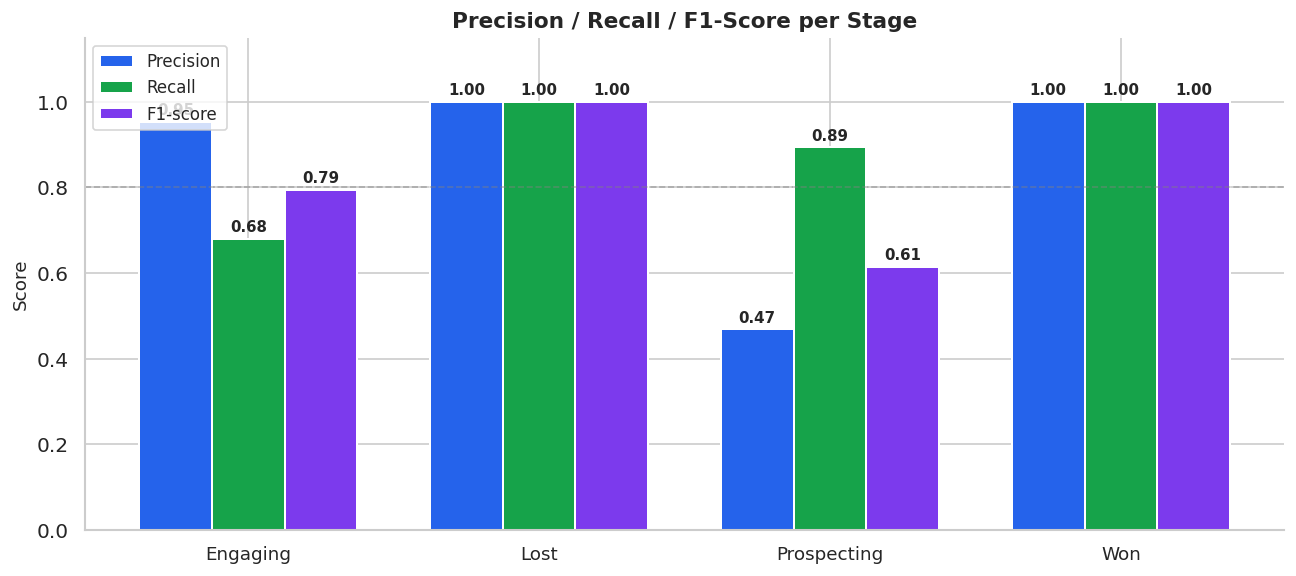

✅ Chart saved.


In [49]:
# ── Visualise per-class metrics as a grouped bar chart ───────────
report_dict = classification_report(
    y_val, y_pred,
    target_names=labels,
    output_dict=True
)

# Extract per-class metrics (skip 'accuracy', 'macro avg', 'weighted avg')
class_metrics = {k: v for k, v in report_dict.items()
                 if k in labels}

metrics_df = pd.DataFrame(class_metrics).T[['precision','recall','f1-score']]

x    = np.arange(len(metrics_df))
w    = 0.25
cols = ['#2563EB', '#16A34A', '#7C3AED']

fig, ax = plt.subplots(figsize=(11, 5))

for i, (metric, colour) in enumerate(zip(['precision','recall','f1-score'], cols)):
    offset = (i - 1) * w
    bars   = ax.bar(x + offset, metrics_df[metric], width=w,
                    color=colour, edgecolor='white',
                    linewidth=1.2, label=metric.capitalize())
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.2f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_df.index, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Precision / Recall / F1-Score per Stage',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'per_class_metrics.png', bbox_inches='tight')
plt.show()
print("✅ Chart saved.")

---
## Step 8 — ROC-AUC Curves

**ROC-AUC** is one of the best ways to evaluate a classifier when classes  
are imbalanced.

### What does it measure?

For each stage, we ask: *"How well does the model separate deals that  
belong to this stage from deals that don't?"*

- **AUC = 1.0** → Perfect separation (model is certain)
- **AUC = 0.5** → Random guessing (no better than a coin flip)
- **AUC > 0.85** → Very good model

### Why one curve per class?

With 4 stages, we use a **One vs Rest** approach:
- Curve 1: "Won" vs everything else
- Curve 2: "Lost" vs everything else
- Curve 3: "Engaging" vs everything else
- Curve 4: "Prospecting" vs everything else

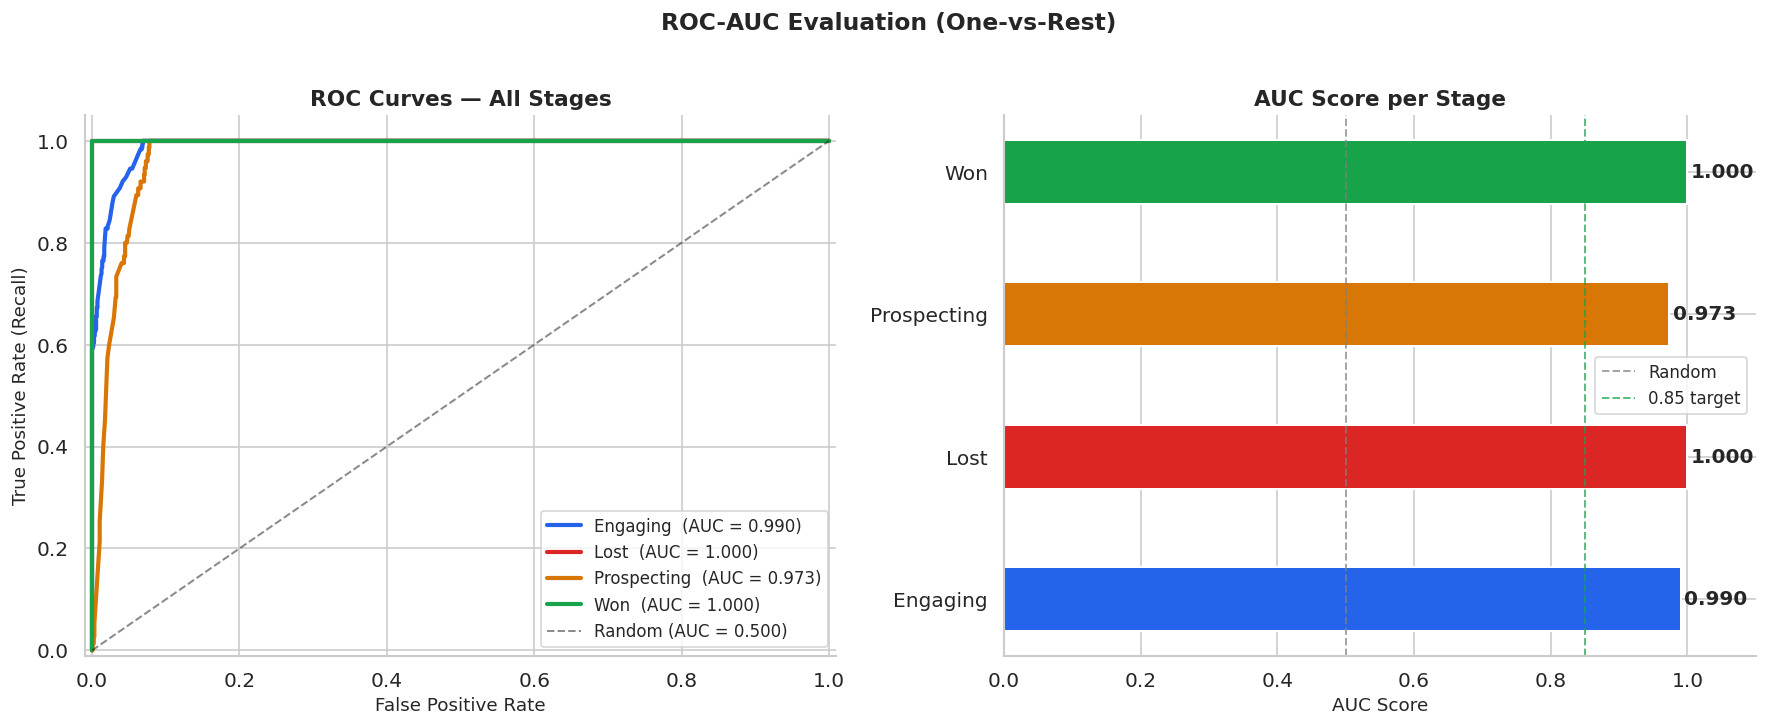

AUC SCORES SUMMARY
-----------------------------------
  Engaging         AUC = 0.990  🟢 Excellent
  Lost             AUC = 1.000  🟢 Excellent
  Prospecting      AUC = 0.973  🟢 Excellent
  Won              AUC = 1.000  🟢 Excellent

  Macro-average AUC : 0.991


In [50]:
# ── Compute ROC curves (One-vs-Rest) ────────────────────────────
n_classes   = len(labels)
stage_order = sorted(STAGE_MAPPING.values())   # [0, 1, 2, 3]

# Binarise y_val: one column per class (shape: n_rows × 4)
y_val_bin = label_binarize(y_val, classes=stage_order)

roc_data = {}
for i, stage_idx in enumerate(stage_order):
    stage_name = IDX_TO_STAGE[stage_idx]
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_prob[:, i])
    roc_auc      = auc(fpr, tpr)
    roc_data[stage_name] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}

# ── Plot ROC curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: all 4 curves on one chart ─────────────────────────────
ax1 = axes[0]
for stage_name, data in roc_data.items():
    colour = STAGE_COLOURS.get(stage_name, '#94A3B8')
    ax1.plot(data['fpr'], data['tpr'],
             color=colour, linewidth=2.5,
             label=f"{stage_name}  (AUC = {data['auc']:.3f})")

ax1.plot([0,1],[0,1], 'k--', linewidth=1.2, alpha=0.5, label='Random (AUC = 0.500)')
ax1.fill_between([0,1],[0,1],[0,1], alpha=0.05, color='gray')

ax1.set_xlim([-0.01, 1.01])
ax1.set_ylim([-0.01, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax1.set_title('ROC Curves — All Stages', fontweight='bold', fontsize=13)
ax1.legend(fontsize=10, loc='lower right')

# ── Right: AUC bar chart ──────────────────────────────────────────
ax2 = axes[1]
stage_names = list(roc_data.keys())
auc_scores  = [roc_data[s]['auc'] for s in stage_names]
colours_list = [STAGE_COLOURS.get(s, '#94A3B8') for s in stage_names]

bars = ax2.barh(stage_names, auc_scores, color=colours_list,
                edgecolor='white', linewidth=1.2, height=0.45)
ax2.axvline(x=0.5, color='gray',    linestyle='--', linewidth=1.2, alpha=0.7, label='Random')
ax2.axvline(x=0.85,color='#16A34A', linestyle='--', linewidth=1.2, alpha=0.7, label='0.85 target')

for bar, score in zip(bars, auc_scores):
    ax2.text(bar.get_width() + 0.005,
             bar.get_y() + bar.get_height()/2,
             f'{score:.3f}',
             va='center', fontsize=12, fontweight='bold')

ax2.set_xlim(0, 1.1)
ax2.set_xlabel('AUC Score', fontsize=11)
ax2.set_title('AUC Score per Stage', fontweight='bold', fontsize=13)
ax2.legend(fontsize=10)

plt.suptitle('ROC-AUC Evaluation (One-vs-Rest)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'roc_auc_curves.png', bbox_inches='tight')
plt.show()

# Print AUC summary
print("AUC SCORES SUMMARY")
print("-" * 35)
for stage, data in roc_data.items():
    grade = '🟢 Excellent' if data['auc']>=0.90 else '🟡 Good' if data['auc']>=0.80 else '🟠 Fair'
    print(f"  {stage:<15}  AUC = {data['auc']:.3f}  {grade}")

macro_auc = np.mean(auc_scores)
print(f"\n  Macro-average AUC : {macro_auc:.3f}")

---
## Step 9 — Feature Importance

Random Forest can tell us **which features matter most** for its predictions.

It measures importance by asking: *"When this feature is used to split the  
data at a tree node, how much does it reduce the prediction error?"*

A high importance score = this feature is heavily relied upon by the model.

> **Why this matters for the business:**  
> If `Amount` has the highest importance, it means deal value is the  
> strongest signal for predicting the stage — a real business insight.

In [52]:
# ── Extract feature importances ──────────────────────────────────
importances = model.feature_importances_
std_dev     = np.std(
    [tree.feature_importances_ for tree in model.estimators_], axis=0
)

importance_df = pd.DataFrame({
    'Feature'    : FEATURE_COLS,
    'Importance' : importances,
    'Std Dev'    : std_dev,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

importance_df['Rank']    = importance_df.index + 1
importance_df['% Share'] = (importance_df['Importance'] * 100).round(2)

print("FEATURE IMPORTANCE RANKING")
print("=" * 52)
display(importance_df[['Rank','Feature','% Share','Std Dev']].round(4))

FEATURE IMPORTANCE RANKING


,Rank,Feature,% Share,Std Dev
0,1,Amount,39.29,0.0493
1,2,Owner_Freq,15.08,0.0419
2,3,Close_Month,8.93,0.1674
3,4,Close_Year,8.85,0.1715
4,5,Close_DayOfWeek,8.52,0.1679
5,6,Deal_Age_Days,8.29,0.1604
6,7,Close_Quarter,8.03,0.1626
7,8,Account_Freq,3.01,0.0398


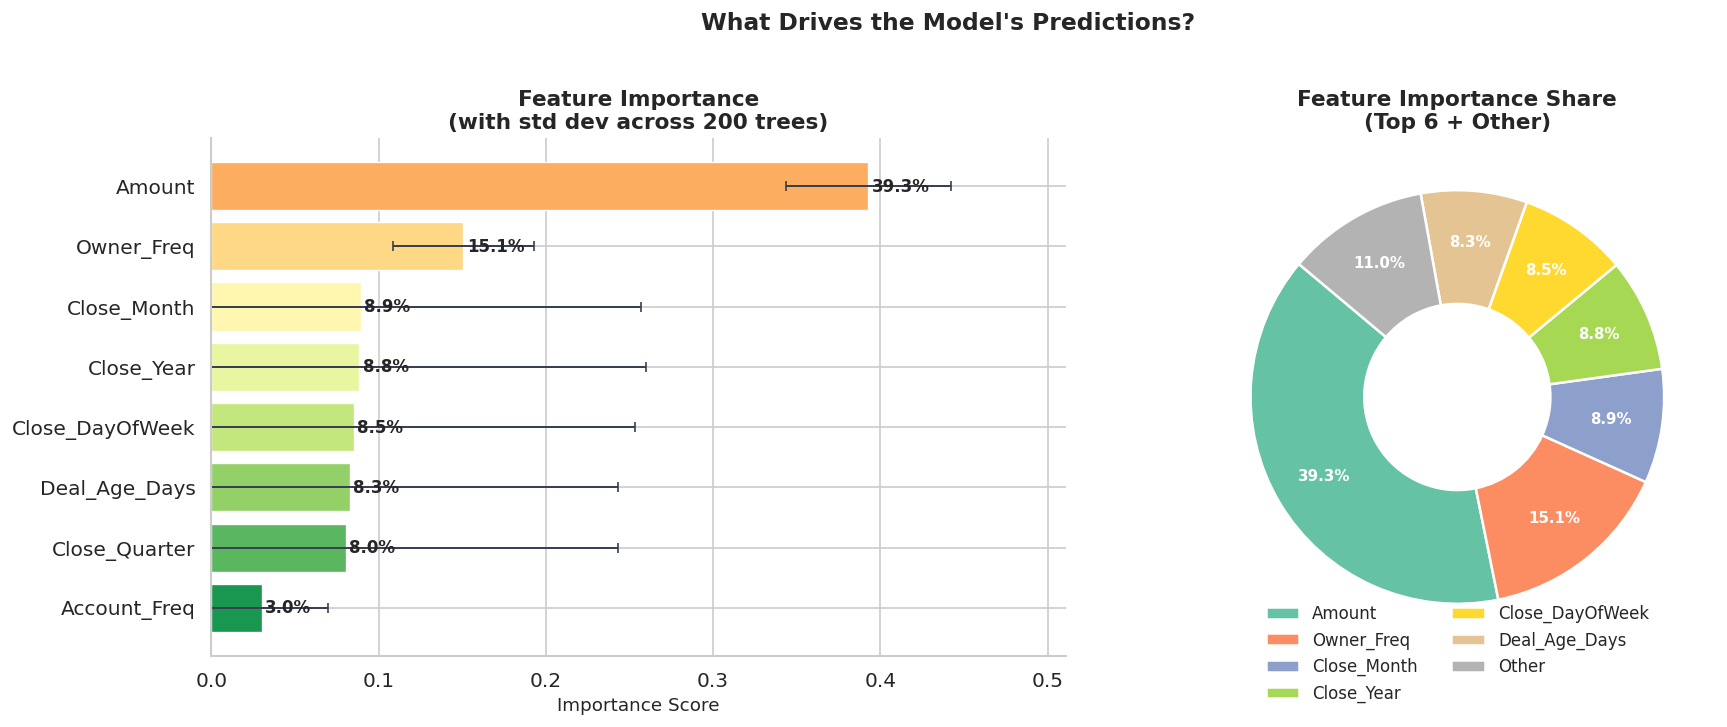

✅ Chart saved as 'model_plots/feature_importance.png'


In [53]:
# ── Visualise feature importances ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: horizontal bar chart with error bars ────────────────────
ax1 = axes[0]
colours_imp = plt.cm.RdYlGn(
    np.linspace(0.3, 0.9, len(importance_df))[::-1])

bars = ax1.barh(
    importance_df['Feature'][::-1],
    importance_df['Importance'][::-1],
    xerr=importance_df['Std Dev'][::-1],
    color=colours_imp,
    edgecolor='white', linewidth=0.8,
    error_kw=dict(elinewidth=1.2, ecolor='#374151', capsize=3),
)

for bar, imp in zip(bars, importance_df['Importance'][::-1]):
    ax1.text(bar.get_width() + 0.002,
             bar.get_y() + bar.get_height()/2,
             f'{imp*100:.1f}%',
             va='center', fontsize=10, fontweight='bold')

ax1.set_xlabel('Importance Score', fontsize=11)
ax1.set_title('Feature Importance\n(with std dev across 200 trees)',
              fontweight='bold', fontsize=13)
ax1.set_xlim(0, importance_df['Importance'].max() * 1.3)

# ── Right: pie chart — share of importance ────────────────────────
ax2 = axes[1]
top_n   = 6
top_imp = importance_df.head(top_n).copy()
other   = importance_df.iloc[top_n:]['Importance'].sum()

labels_pie  = top_imp['Feature'].tolist() + (['Other' ] if other > 0 else [])
values_pie  = top_imp['Importance'].tolist() + ([other] if other > 0 else [])
colours_pie = plt.cm.Set2(np.linspace(0, 1, len(labels_pie)))

wedges, texts, autotexts = ax2.pie(
    values_pie,
    labels=None,
    colors=colours_pie,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5),
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color('white')
    at.set_fontweight('bold')

ax2.legend(wedges, labels_pie,
           loc='lower center', bbox_to_anchor=(0.5, -0.12),
           ncol=2, fontsize=10, frameon=False)
ax2.set_title(f'Feature Importance Share\n(Top {top_n} + Other)',
              fontweight='bold', fontsize=13)

plt.suptitle("What Drives the Model's Predictions?",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_importance.png', bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'model_plots/feature_importance.png'")

In [54]:
# ── Business interpretation ──────────────────────────────────────
top_feature = importance_df.iloc[0]['Feature']
top_pct     = importance_df.iloc[0]['% Share']

print("FEATURE IMPORTANCE — BUSINESS INTERPRETATION")
print("=" * 52)
print()

for _, row in importance_df.iterrows():
    bar = '█' * int(row['% Share'] / 2)
    print(f"  {int(row['Rank']):>2}. {row['Feature']:<20}  {row['% Share']:>5.1f}%  {bar}")

print()
print(f"  → Most important feature: '{top_feature}' ({top_pct:.1f}% of model's decisions)")
print()
print("  Interpretation guide:")
print("  > 20% → Critical signal   | 10–20% → Strong signal")
print("  5–10% → Moderate signal   | < 5%   → Weak signal")

FEATURE IMPORTANCE — BUSINESS INTERPRETATION

   1. Amount                 39.3%  ███████████████████
   2. Owner_Freq             15.1%  ███████
   3. Close_Month             8.9%  ████
   4. Close_Year              8.8%  ████
   5. Close_DayOfWeek         8.5%  ████
   6. Deal_Age_Days           8.3%  ████
   7. Close_Quarter           8.0%  ████
   8. Account_Freq            3.0%  █

  → Most important feature: 'Amount' (39.3% of model's decisions)

  Interpretation guide:
  > 20% → Critical signal   | 10–20% → Strong signal
  5–10% → Moderate signal   | < 5%   → Weak signal


---
## Step 10 — Predict a Single New Deal

This simulates what happens when a **brand-new deal** comes in from Zoho.  
We preprocess it exactly the same way as the training data, then ask  
the model for a prediction.

In [55]:
# ── Load the preprocessing function from Phase 2 ─────────────────
# (paste the function here if running in a fresh kernel)

def preprocess_new_deal(raw_deal: dict,
                        scaler,
                        freq_maps: dict,
                        feature_cols: list) -> pd.DataFrame:
    """
    Transforms a single raw deal dictionary into a scaled feature
    vector ready for model inference.

    Args:
        raw_deal     : dict with keys: Owner_Name, Account_Name,
                       Amount, Closing_Date
        scaler       : fitted StandardScaler
        freq_maps    : dict with 'owner_freq' and 'account_freq' maps
        feature_cols : list of feature column names in the correct order

    Returns:
        pd.DataFrame with one row, ready to pass to model.predict()
    """
    # ── Convert to DataFrame ──────────────────────────────────────
    df_new = pd.DataFrame([raw_deal])

    # ── Parse date ────────────────────────────────────────────────
    df_new['Closing_Date'] = pd.to_datetime(df_new['Closing_Date'])

    # ── Feature Engineering ───────────────────────────────────────
    df_new['Close_Year']      = df_new['Closing_Date'].dt.year
    df_new['Close_Month']     = df_new['Closing_Date'].dt.month
    df_new['Close_Quarter']   = df_new['Closing_Date'].dt.quarter
    df_new['Close_DayOfWeek'] = df_new['Closing_Date'].dt.dayofweek
    df_new['Deal_Age_Days']   = 0   # Unknown for a brand-new deal

    # ── Frequency Encoding ────────────────────────────────────────
    # Use .get() with a fallback of 1 for unseen owners/accounts
    df_new['Owner_Freq']   = df_new['Owner_Name'].map(
        lambda x: freq_maps['owner_freq'].get(x, 1))
    df_new['Account_Freq'] = df_new['Account_Name'].map(
        lambda x: freq_maps['account_freq'].get(x, 1))

    # ── Select and order features ─────────────────────────────────
    X_new = df_new[feature_cols].copy()

    # ── Scale ─────────────────────────────────────────────────────
    X_scaled = scaler.transform(X_new)
    X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

    return X_scaled_df





In [56]:
# ── A brand new deal from Zoho ────────────────────────────────────
new_deal = {
    'Owner_Name'   : 'Moses Frase',
    'Account_Name' : 'Cancity',
    'Amount'       : 3750.0,
    'Closing_Date' : '2024-06-15',
}

In [57]:


# Preprocess
X_new_scaled = preprocess_new_deal(new_deal, scaler, freq_maps, FEATURE_COLS)
X_new_scaled.head()

,Amount,Close_Month,Close_Year,Close_Quarter,Close_DayOfWeek,Deal_Age_Days,Owner_Freq,Account_Freq
0,1.247715,0.116298,0.566251,0.057631,1.2179,-1.15393,-0.612725,-0.432471


In [58]:
# Predict
pred_idx    = model.predict(X_new_scaled)[0]
pred_stage  = IDX_TO_STAGE[pred_idx]
pred_probs  = model.predict_proba(X_new_scaled)[0]
confidence  = max(pred_probs) * 100

In [59]:

print("NEW DEAL — PREDICTION RESULT")
print("=" * 48)
print()
print(f"  Input deal:")
for k, v in new_deal.items():
    print(f"    {k:<15}: {v}")
print()
print(f"  Predicted Stage : {pred_stage}")
print(f"  Confidence      : {confidence:.1f}%")
print()
print("  Probability breakdown:")
for class_idx, prob in enumerate(pred_probs):
    stage = IDX_TO_STAGE[class_idx]
    bar   = '█' * int(prob * 30)
    arrow = ' ← predicted' if class_idx == pred_idx else ''
    print(f"    {stage:<15} {prob*100:>5.1f}%  {bar}{arrow}")

NEW DEAL — PREDICTION RESULT

  Input deal:
    Owner_Name     : Moses Frase
    Account_Name   : Cancity
    Amount         : 3750.0
    Closing_Date   : 2024-06-15

  Predicted Stage : Won
  Confidence      : 97.9%

  Probability breakdown:
    Engaging          0.0%  
    Lost              2.1%  
    Prospecting       0.0%  
    Won              97.9%  █████████████████████████████ ← predicted


---
## Step 11 — Save the Trained Model

We save the model to disk so we can load it later in:
- **Phase 4** (FastAPI endpoint)
- **Phase 5** (full end-to-end integration)

We also save a model metadata file with performance metrics.

In [60]:
# ── Save the model ───────────────────────────────────────────────
model_path = MODEL_DIR / 'random_forest_v1.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)
print(f"✅ Model saved     : {model_path}")

# ── Save model metadata ───────────────────────────────────────────
metadata = {
    'model_name'     : 'RandomForestClassifier',
    'model_version'  : 'v1.0.0',
    'n_estimators'   : model.n_estimators,
    'class_weight'   : 'balanced',
    'feature_cols'   : FEATURE_COLS,
    'stage_classes'  : label_enc.classes_.tolist(),
    'stage_mapping'  : STAGE_MAPPING,
    'performance': {
        'validation_accuracy'  : round(float(accuracy), 4),
        'validation_precision' : round(float(precision), 4),
        'validation_recall'    : round(float(recall), 4),
        'validation_f1'        : round(float(f1), 4),
        'auc_per_class'        : {
            s: round(roc_data[s]['auc'], 4) for s in roc_data
        },
        'macro_auc'            : round(float(macro_auc), 4),
    },
    'feature_importance': importance_df[['Feature','% Share']].to_dict('records'),
}

meta_path = MODEL_DIR / 'model_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Metadata saved  : {meta_path}")

# ── List all saved files ──────────────────────────────────────────
print()
print("── All saved model artefacts ─────────────────────────────────")
for path in sorted(MODEL_DIR.iterdir()):
    size_kb = path.stat().st_size / 1024
    print(f"   {path.name:<35}  {size_kb:>6.1f} KB")

✅ Model saved     : /kaggle/working/weights/random_forest_v1.pkl
✅ Metadata saved  : /kaggle/working/weights/model_metadata.json

── All saved model artefacts ─────────────────────────────────
   model_metadata.json                     1.3 KB
   random_forest_v1.pkl                 15561.4 KB


In [ ]:
# ── How to reload the model in Phase 4 ──────────────────────────
print("""
── Copy this into Phase 4 (FastAPI) to reload the model ──────────

import pickle, json
from pathlib import Path

MODEL_DIR = Path('model_artefacts')

with open(MODEL_DIR / 'random_forest_v1.pkl', 'rb') as f:
    model = pickle.load(f)

with open(MODEL_DIR / 'model_metadata.json') as f:
    metadata = json.load(f)

FEATURE_COLS  = metadata['feature_cols']
STAGE_MAPPING = metadata['stage_mapping']
IDX_TO_STAGE  = {v: k for k, v in STAGE_MAPPING.items()}

print('✅ Model reloaded — ready to predict.')
""")

---
## Step 12 — Phase 3 Summary

In [61]:
print("=" * 60)
print("  PHASE 3 SUMMARY — Model Training & Evaluation")
print("=" * 60)

print(f"\n🤖 MODEL")
print(f"   Algorithm        : Random Forest Classifier")
print(f"   Trees            : {model.n_estimators}")
print(f"   Class weighting  : balanced (handles imbalanced stages)")
print(f"   Training rows    : {X_train.shape[0]:,}")

print(f"\n📊 PERFORMANCE (Validation Set)")
print(f"   Accuracy   : {accuracy*100:.2f}%")
print(f"   Precision  : {precision*100:.2f}%")
print(f"   Recall     : {recall*100:.2f}%")
print(f"   F1-Score   : {f1*100:.2f}%")
print(f"   Macro AUC  : {macro_auc:.3f}")

print(f"\n🏆 TOP 3 MOST IMPORTANT FEATURES")
for _, row in importance_df.head(3).iterrows():
    print(f"   {int(row['Rank'])}. {row['Feature']:<20}  {row['% Share']:.1f}%")

print(f"\n📈 AUC SCORES PER STAGE")
for stage, data in roc_data.items():
    grade = '🟢' if data['auc'] >= 0.90 else '🟡' if data['auc'] >= 0.80 else '🟠'
    print(f"   {grade} {stage:<15}  {data['auc']:.3f}")

print(f"\n📦 SAVED FILES")
for path in sorted(MODEL_DIR.iterdir()):
    print(f"   {path.name}")
for path in sorted(PLOTS_DIR.iterdir()):
    print(f"   {path.name}")

print()
print("=" * 60)
print("  Phase 3 Complete — Ready for Phase 4: FastAPI Deployment")
print("=" * 60)

  PHASE 3 SUMMARY — Model Training & Evaluation

🤖 MODEL
   Algorithm        : Random Forest Classifier
   Trees            : 1000
   Class weighting  : balanced (handles imbalanced stages)
   Training rows    : 6,160

📊 PERFORMANCE (Validation Set)
   Accuracy   : 93.64%
   Precision  : 96.13%
   Recall     : 93.64%
   F1-Score   : 94.10%
   Macro AUC  : 0.991

🏆 TOP 3 MOST IMPORTANT FEATURES
   1. Amount                39.3%
   2. Owner_Freq            15.1%
   3. Close_Month           8.9%

📈 AUC SCORES PER STAGE
   🟢 Engaging         0.990
   🟢 Lost             1.000
   🟢 Prospecting      0.973
   🟢 Won              1.000

📦 SAVED FILES
   model_metadata.json
   random_forest_v1.pkl
   confusion_matrix.png
   feature_importance.png
   per_class_metrics.png
   performance_metrics.png
   roc_auc_curves.png

  Phase 3 Complete — Ready for Phase 4: FastAPI Deployment


---

## ✅ Phase 3 Complete!

### What we built

| Step | What we did | Output |
|---|---|---|
| Defined model | RandomForest, 200 trees, balanced weights | Configured model |
| Trained | Fit on 70% of data | Trained model object |
| Predicted | Ran on validation set | `y_pred`, `y_prob` |
| Accuracy | Overall correctness | Single % score |
| Confusion matrix | Where does it get confused? | 4×4 matrix |
| Classification report | Per-class Precision/Recall/F1 | Report table |
| ROC-AUC | How well does it separate classes? | AUC per stage |
| Feature importance | What drives predictions? | Ranked feature list |
| Single deal prediction | End-to-end inference test | Stage + confidence |
| Saved model | Persisted to disk | `random_forest_v1.pkl` |

### Charts saved to `model_plots/`

| File | Contents |
|---|---|
| `performance_metrics.png` | Accuracy / Precision / Recall / F1 bar chart |
| `confusion_matrix.png` | Raw counts + row-normalised heatmaps |
| `per_class_metrics.png` | Grouped bars per stage |
| `roc_auc_curves.png` | ROC curves + AUC bar chart |
| `feature_importance.png` | Horizontal bars + pie share |

---

> **Ready for the next step?**  
> Tell the AI: **"Continue to Phase 4 — FastAPI Deployment"**